In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("helmetdetection-bolsj").project("helmet_detection-jctve")
version = project.version(1)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...


In [1]:
dataset.location

NameError: name 'dataset' is not defined

In [ ]:
!nvidia-smi

Thu Mar 27 14:35:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P0             11W /   60W |       8MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
Setup complete ✅ (12 CPUs, 15.0 GB RAM, 32.1/61.2 GB disk)


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
torch.cuda.empty_cache()

True
1


In [2]:
from ultralytics import YOLO


model = YOLO("yolo11n.pt")


train_results = model.train(
    data="/home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/data.yaml",  # path to dataset YAML
    epochs = 60,  # number of training epochs
    imgsz = 1024, # training image size
    device ="0",  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
    optimizer = "AdamW",
    lr0 = 0.001,
    batch = 8,
    mosaic = 1.0,
    patience = 20,
    weight_decay=0.0005,
)

New https://pypi.org/project/ultralytics/8.3.97 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/data.yaml, epochs=60, time=None, patience=20, batch=8, imgsz=1024, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train37, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fals

train: Scanning /home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/train/labels.cache... 1536 images, 22 backgrounds, 0 corrupt: 100%|██████████| 1536/1536 [00:00<?, ?it/s]
val: Scanning /home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/valid/labels.cache... 146 images, 0 backgrounds, 0 corrupt: 100%|██████████| 146/146 [00:00<?, ?it/s]


Plotting labels to runs/detect/train37/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 1024 train, 1024 val
Using 8 dataloader workers
Logging results to runs/detect/train37
Starting training for 60 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/60      2.74G      1.979      3.053      1.843         35       1024: 100%|██████████| 192/192 [00:47<00:00,  4.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:01<00:00,  5.81it/s]

                   all        146        338        0.3      0.208      0.194     0.0801


...

      47/60      2.74G       1.31      1.071      1.397         24       1024: 100%|██████████| 192/192 [00:46<00:00,  4.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:01<00:00,  6.14it/s]

                   all        146        338      0.604      0.504      0.497      0.277
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 27, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



47 epochs completed in 0.664 hours.
Optimizer stripped from runs/detect/train37/weights/last.pt, 5.6MB
Optimizer stripped from runs/detect/train37/weights/best.pt, 5.6MB

Validating runs/detect/train37/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:02<00:00,  4.69it/s]


                   all        146        338      0.642      0.552       0.57       0.29
                helmet        106        219      0.762      0.616      0.684      0.422
        without helmet         61        119      0.522      0.487      0.457      0.158
Speed: 0.8ms preprocess, 8.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs/detect/train37


RESULTS

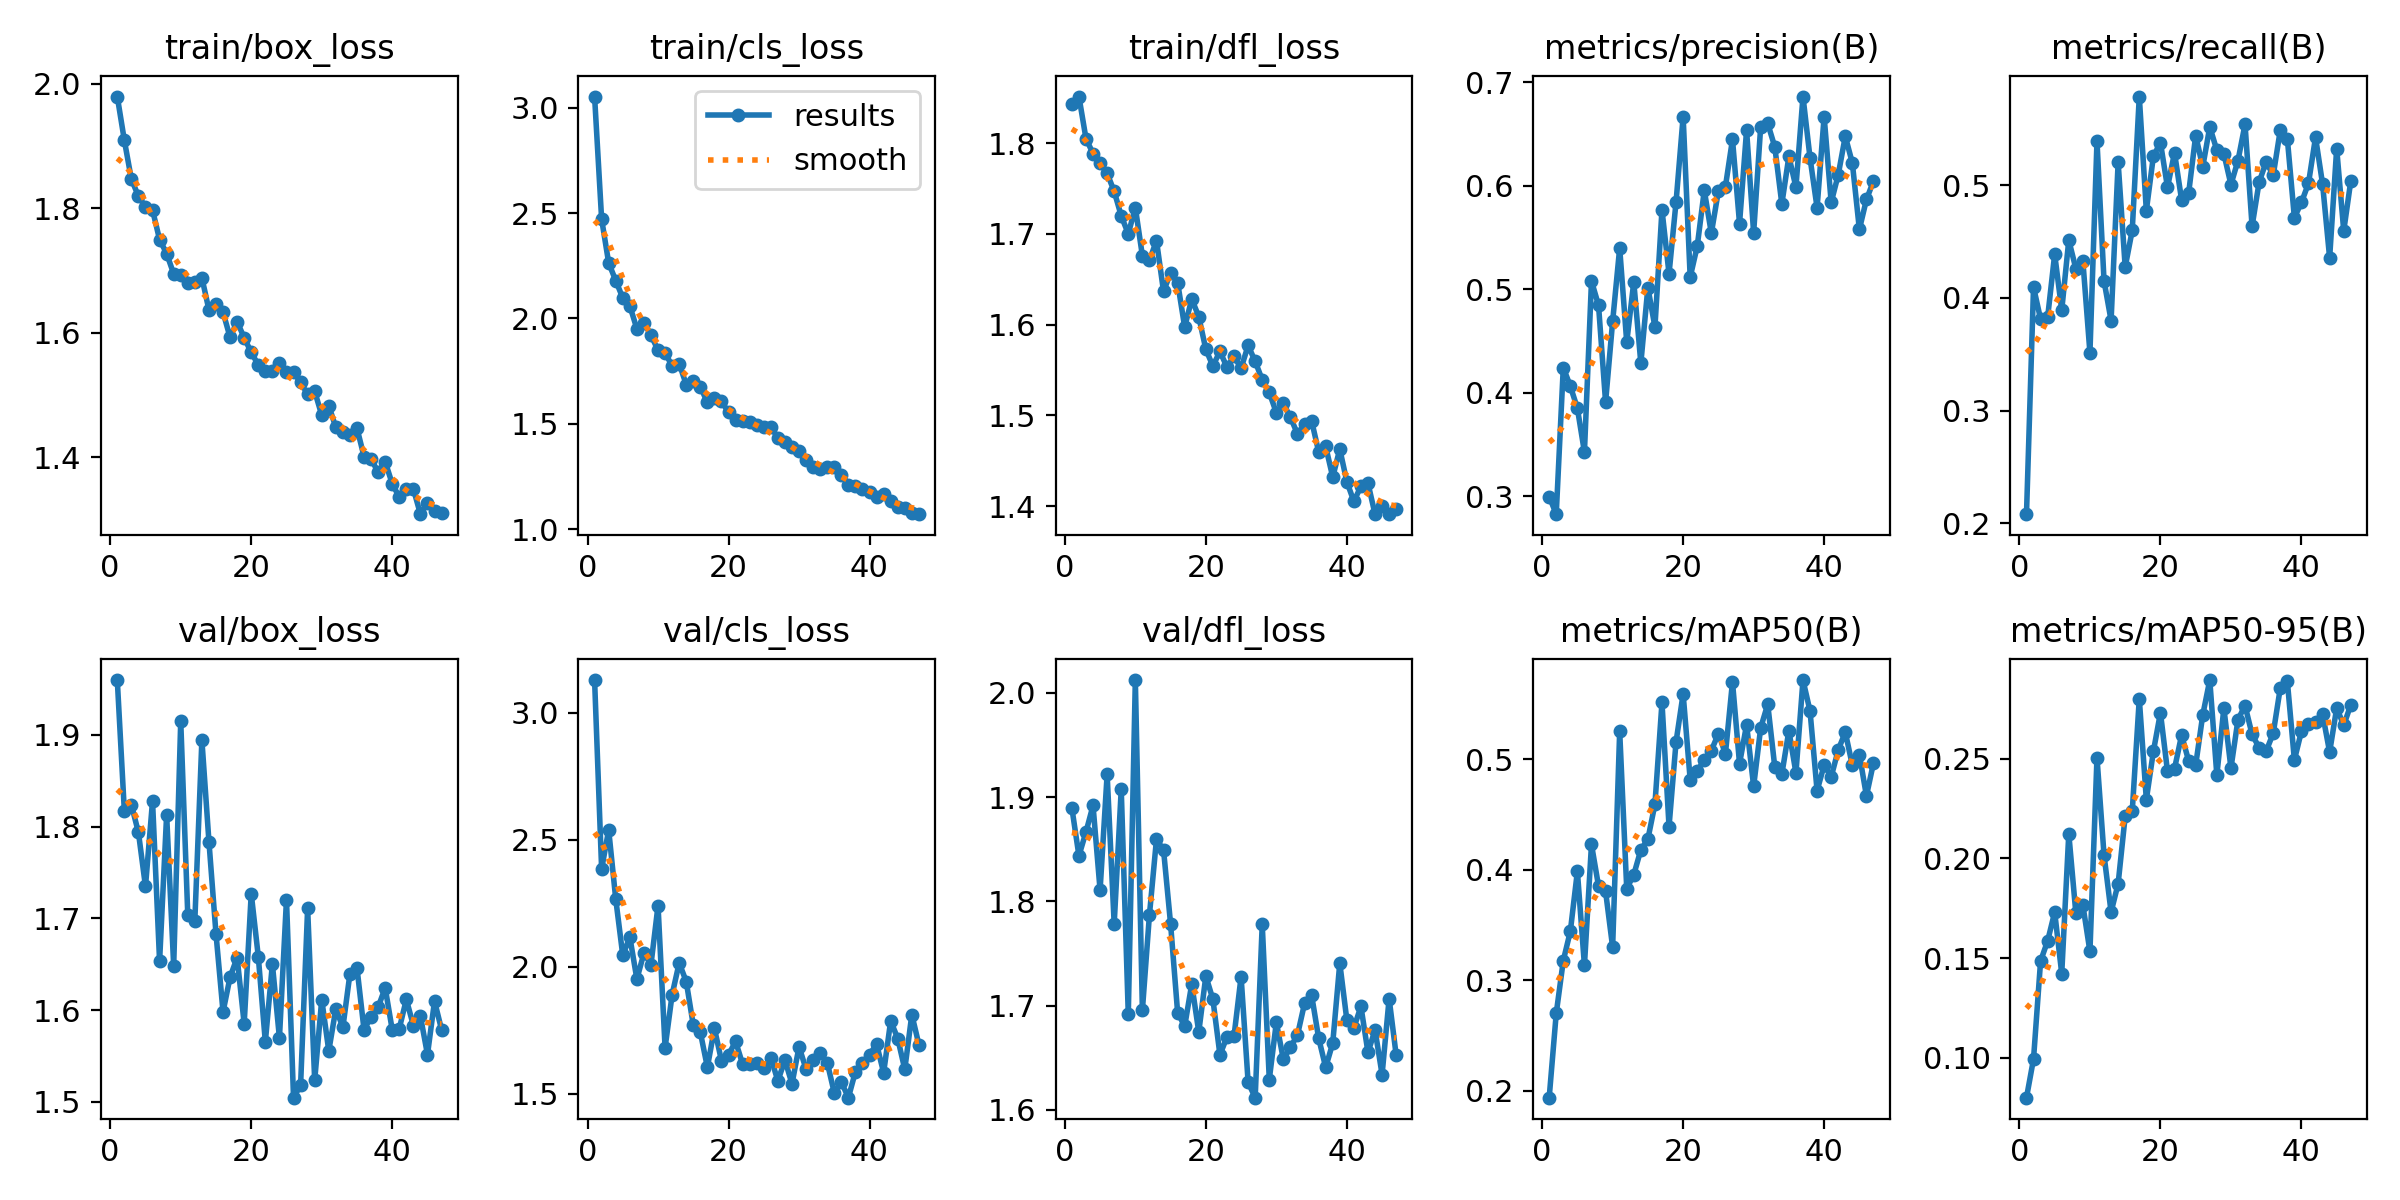

In [3]:
from IPython.display import Image, Markdown

display(Markdown("RESULTS"))
Image("/home/syssoni/Documents/Python/helmet_detection/runs/detect/train37/results.png", width=1000, height=1000)



Confusion_Matrix

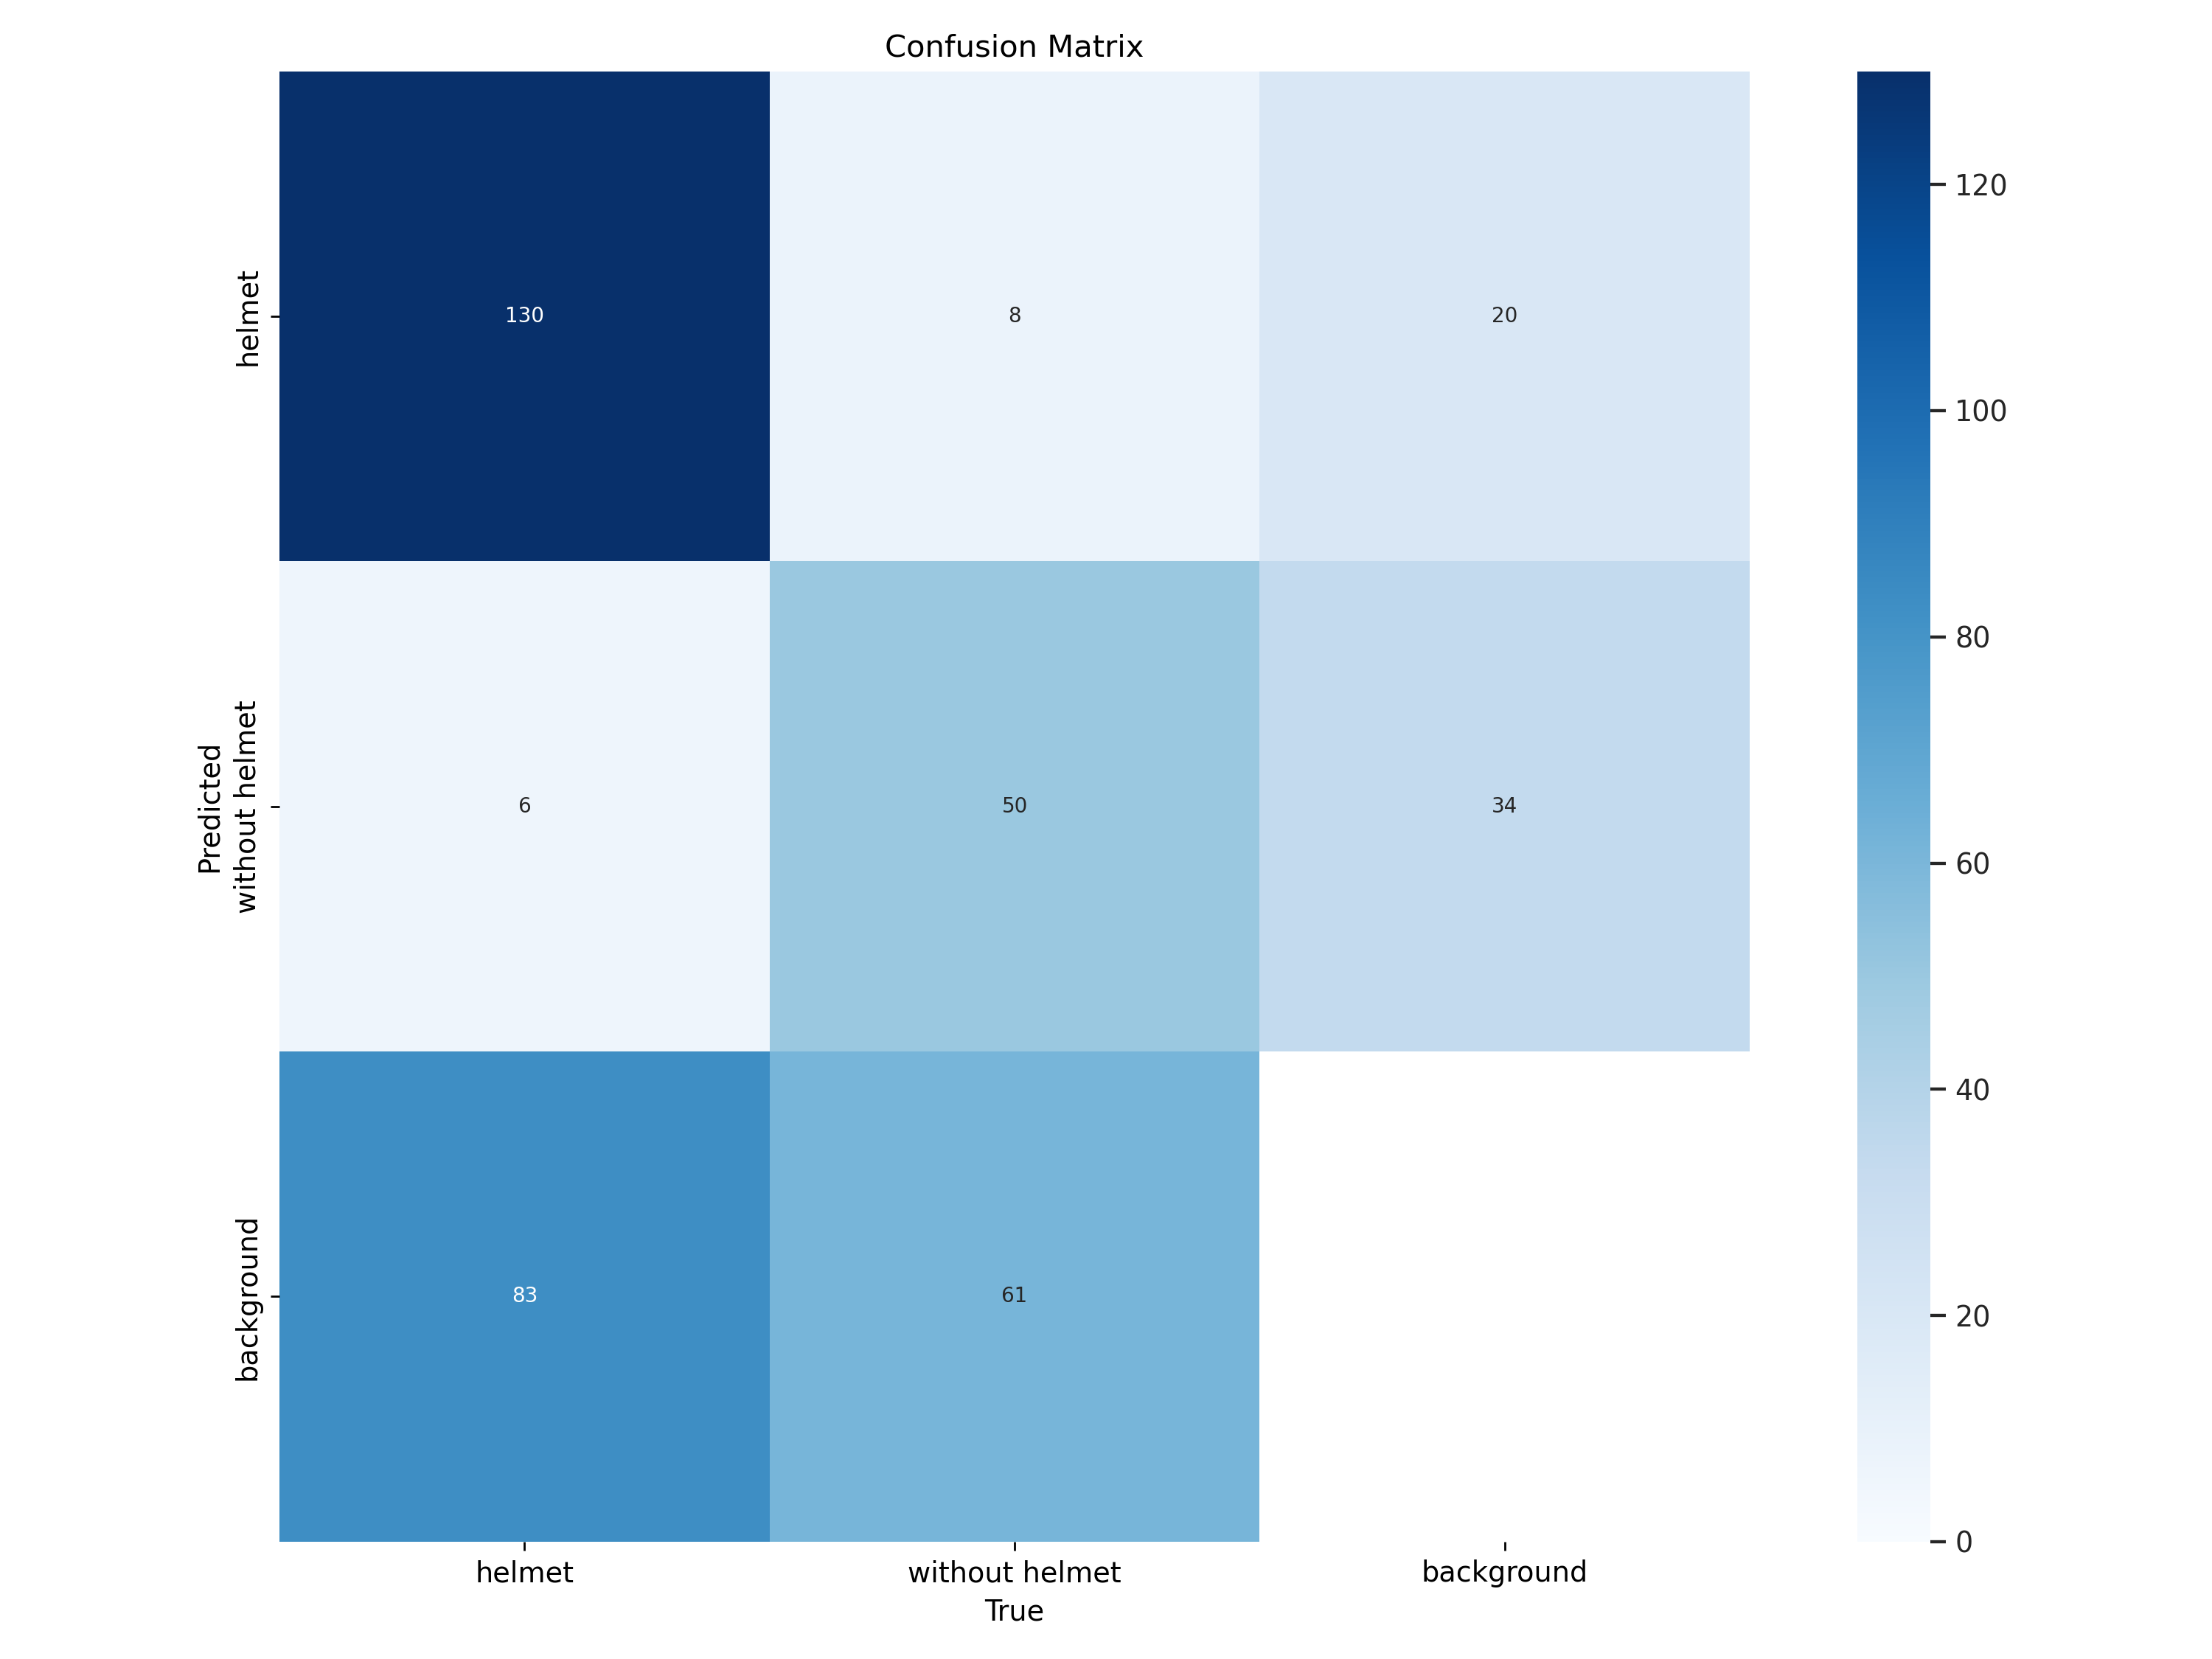

In [4]:
display(Markdown("Confusion_Matrix"))
Image("/home/syssoni/Documents/Python/helmet_detection/runs/detect/train37/confusion_matrix.png",width=1000, height=1000)

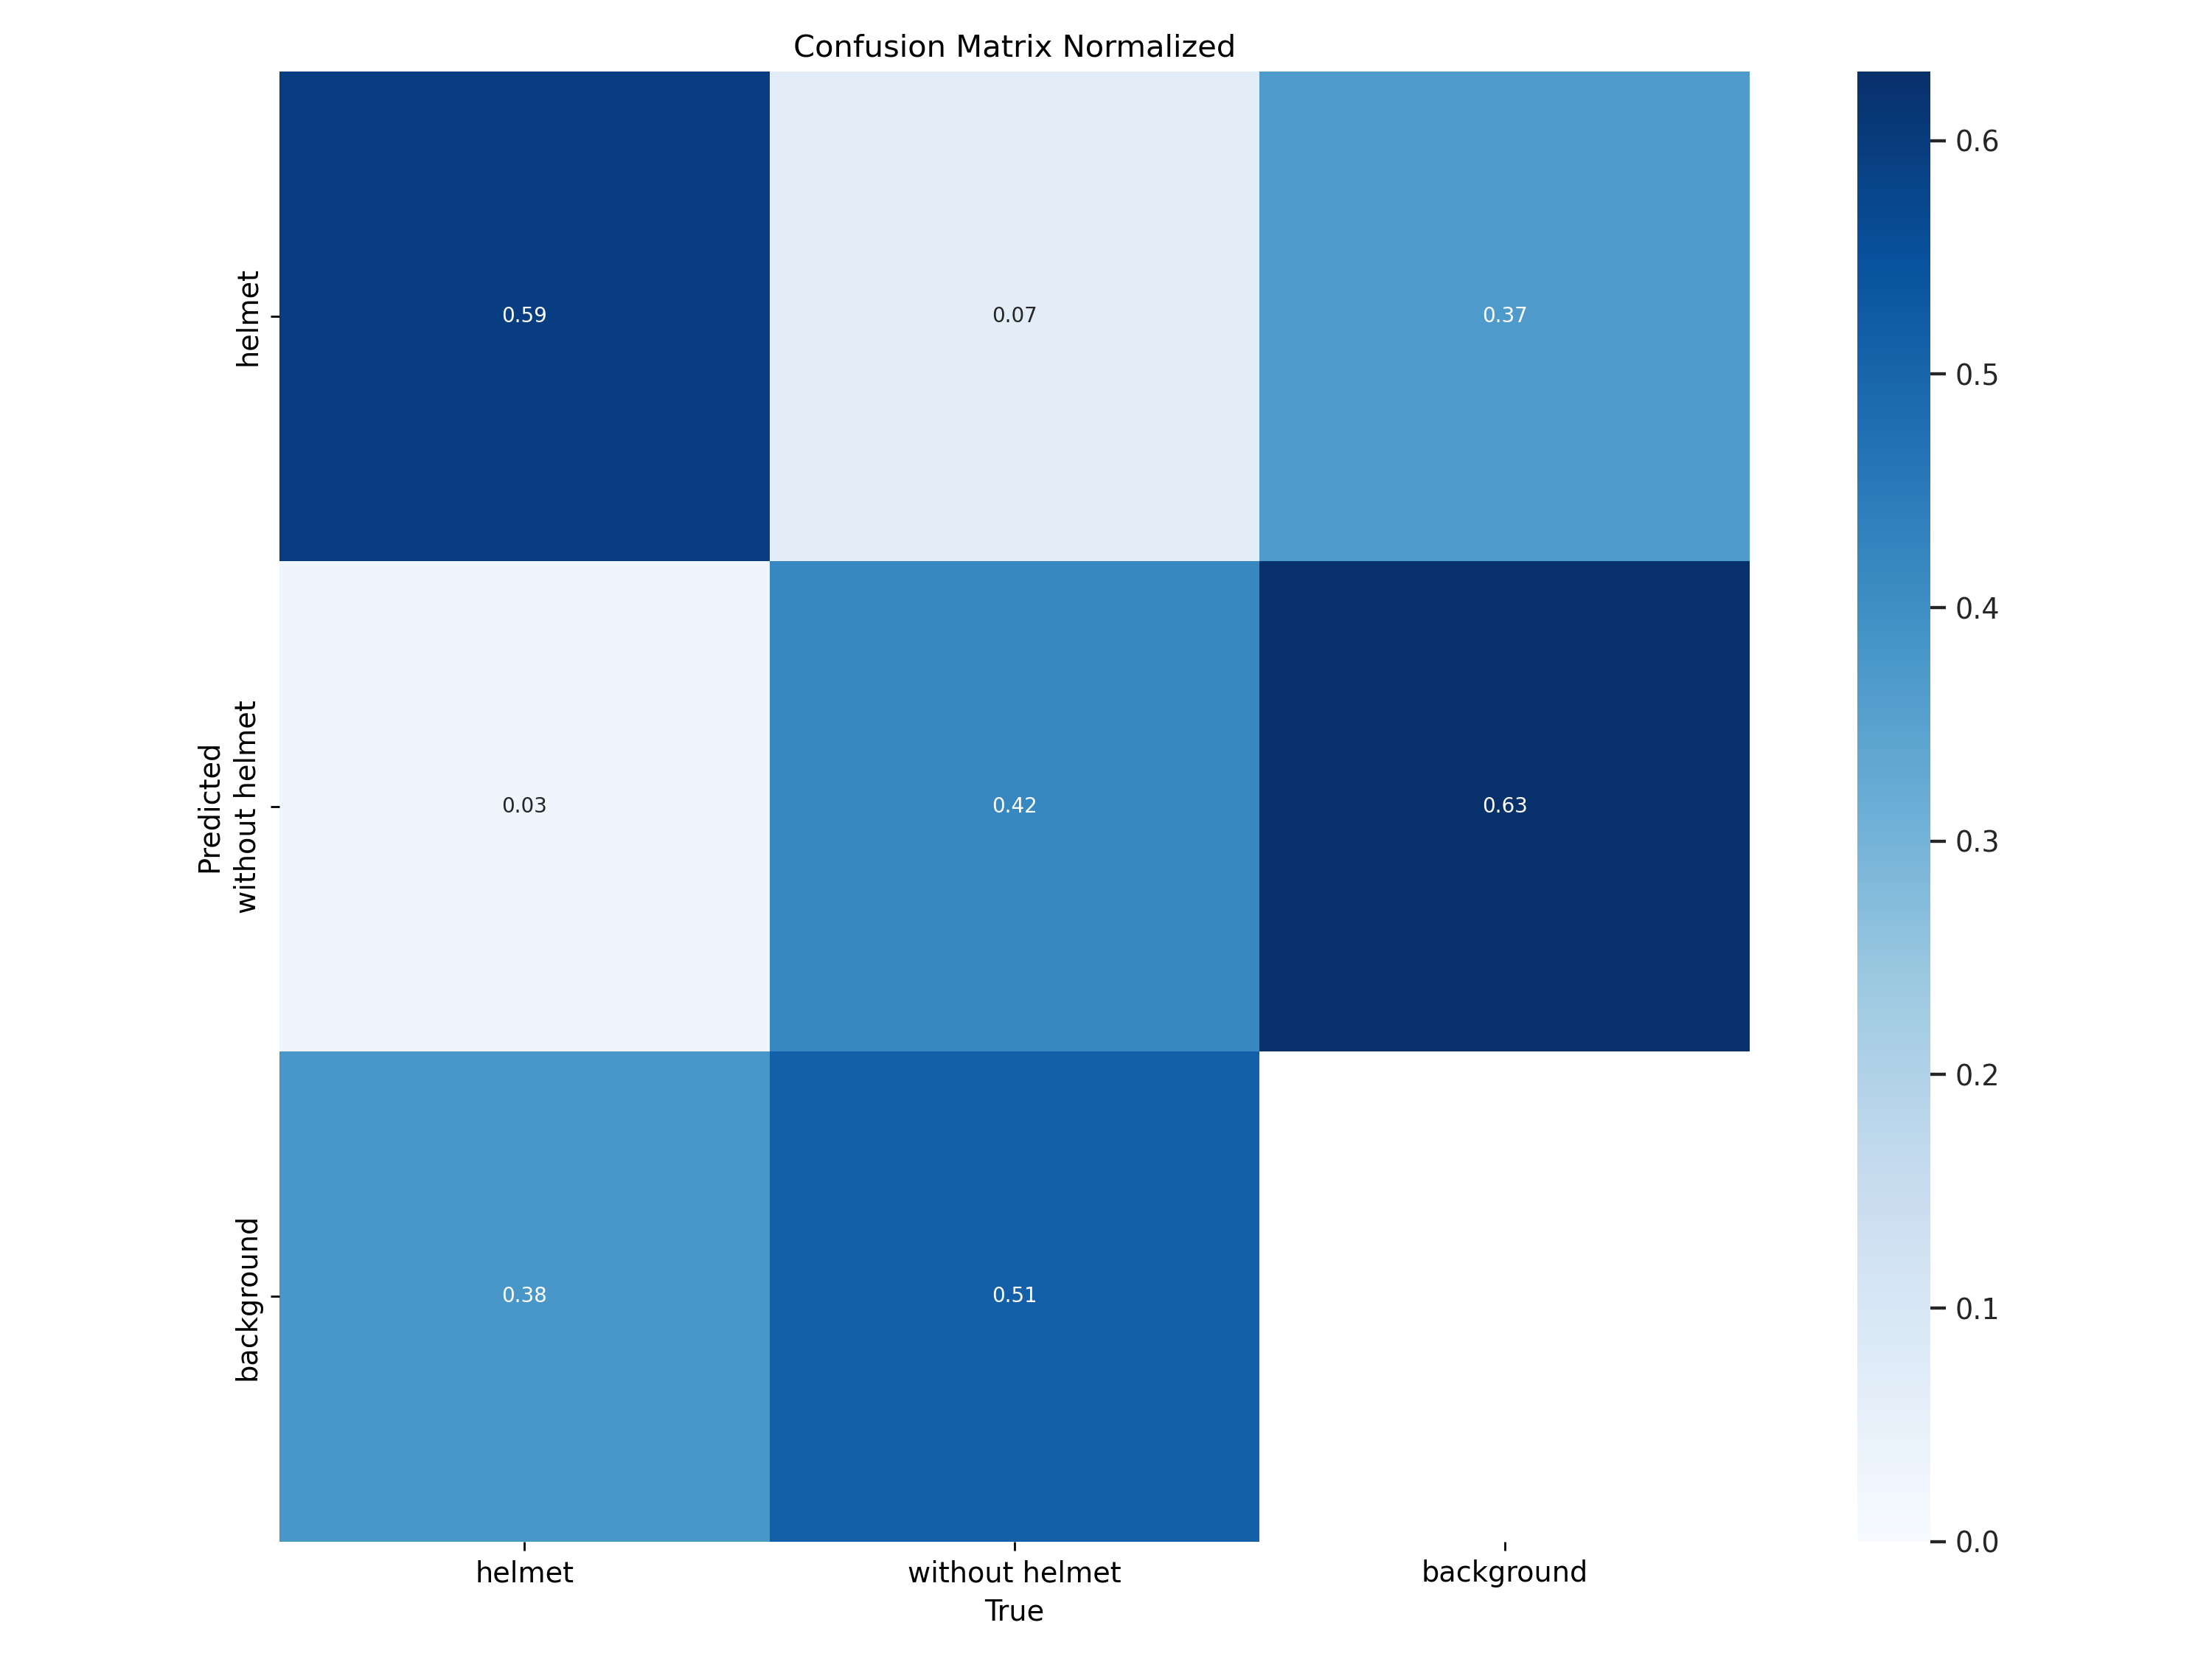

In [7]:
Image("/home/syssoni/Documents/Python/helmet_detection/runs/detect/train37/confusion_matrix_normalized.png", width=1000, height=1000)

In [5]:
val_results = model.val(
    data="/home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/data.yaml",
    imgsz = 640,
    device = "0"
)

Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/valid/labels.cache... 146 images, 0 backgrounds, 0 corrupt: 100%|██████████| 146/146 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:01<00:00, 12.50it/s]


                   all        146        338      0.726      0.519      0.601      0.308
                helmet        106        219      0.809      0.612      0.707      0.436
        without helmet         61        119      0.644      0.426      0.495       0.18
Speed: 1.0ms preprocess, 6.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/train372


In [ ]:
display(Markdown("VALIDATION: Confusion Matrix"))
Image("/home/syssoni/Documents/Python/helmet_detection/yolov12/runs/detect/372/confusion_matrix.png", width=800, height=800)

In [6]:
test_results = model.val(
    data="/home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/data.yaml",
    split = "test",
    imgsz = 640,
    device = "0"
)

Ultralytics 8.3.96 🚀 Python-3.13.2 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)


val: Scanning /home/syssoni/Documents/Python/helmet_detection/helmet_detection-1/test/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100%|██████████| 74/74 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:00<00:00, 10.56it/s]


                   all         74        170      0.809      0.504       0.63      0.283
                helmet         50        107      0.787      0.542      0.637      0.316
        without helmet         30         63       0.83      0.466      0.623       0.25
Speed: 1.4ms preprocess, 5.0ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/train373


code left for yolov12